In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
right_list = glob.glob('/data/choihy/study_0630/data/left/*')
left_list = glob.glob('/data/choihy/study_0630/data/right/*')
right_list.sort()
left_list.sort()

In [17]:
i=200
right = cv2.imread(right_list[i])
left = cv2.imread(left_list[i])
img1 = left.copy()
img2 = right.copy()

/home/super/anaconda3/envs/hat/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/super/anaconda3/envs/hat/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/super/anaconda3/envs/hat/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 45208 (\N{HANGUL SYLLABLE NA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/super/anaconda3/envs/hat/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 50676 (\N{HANGUL SYLLABLE YEOL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


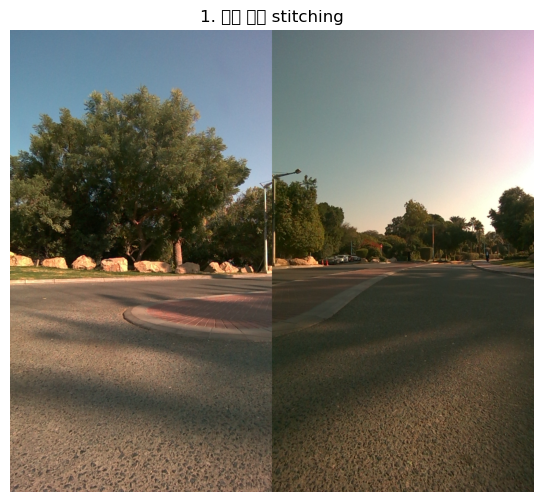

/home/super/anaconda3/envs/hat/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/super/anaconda3/envs/hat/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/super/anaconda3/envs/hat/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 47148 (\N{HANGUL SYLLABLE RYEOL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


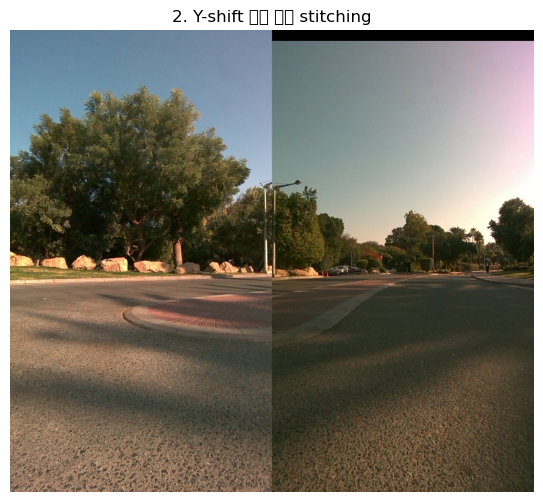

/home/super/anaconda3/envs/hat/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 51088 (\N{HANGUL SYLLABLE JA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/super/anaconda3/envs/hat/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


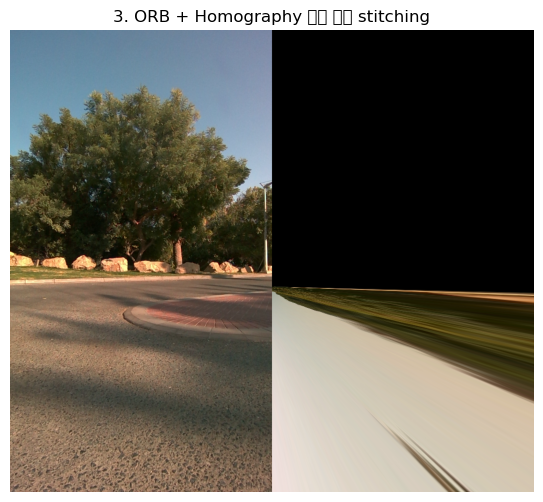

/home/super/anaconda3/envs/hat/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/super/anaconda3/envs/hat/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 48660 (\N{HANGUL SYLLABLE BEUL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/super/anaconda3/envs/hat/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 47116 (\N{HANGUL SYLLABLE REN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/home/super/anaconda3/envs/hat/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 46377 (\N{HANGUL SYLLABLE DING}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


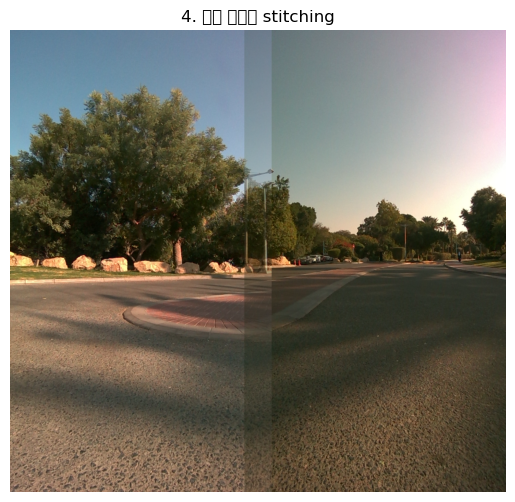

In [18]:
assert img1 is not None and img2 is not None, "이미지를 불러올 수 없습니다."

# 높이 맞추기
h = min(img1.shape[0], img2.shape[0])
img1 = cv2.resize(img1, (int(img1.shape[1] * h / img1.shape[0]), h))
img2 = cv2.resize(img2, (int(img2.shape[1] * h / img2.shape[0]), h))

# === 시각화 함수 ===
def show(title, image):
    plt.figure(figsize=(12, 6))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

# === 1. 수평 나열 stitching ===
def stitch_hstack(img1, img2):
    return np.hstack((img1, img2))

# === 2. 수동 Y-shift 적용 stitching ===
def stitch_shift(img1, img2, shift_y=20):
    h, w = img2.shape[:2]
    M = np.float32([[1, 0, 0], [0, 1, shift_y]])
    img2_shifted = cv2.warpAffine(img2, M, (w, h))
    return np.hstack((img1, img2_shifted))

# === 3. ORB + RANSAC 기반 Homography 자동 정합 ===
def stitch_orb_homography(img1, img2):
    orb = cv2.ORB_create(1000)
    kp1, des1 = orb.detectAndCompute(img1, None)
    kp2, des2 = orb.detectAndCompute(img2, None)

    if des1 is None or des2 is None:
        print("❌ 특징점 추출 실패.")
        return np.hstack((img1, img2))

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)

    if len(matches) < 4:
        print("❗ 대응점이 충분하지 않습니다.")
        return np.hstack((img1, img2))

    src_pts = np.float32([kp1[m.queryIdx].pt for m in matches]).reshape(-1, 1, 2)
    dst_pts = np.float32([kp2[m.trainIdx].pt for m in matches]).reshape(-1, 1, 2)

    H, _ = cv2.findHomography(dst_pts, src_pts, cv2.RANSAC)
    warped_img2 = cv2.warpPerspective(img2, H, (img1.shape[1] + img2.shape[1], img1.shape[0]))
    warped_img2[0:img1.shape[0], 0:img1.shape[1]] = img1
    return warped_img2

# === 4. 겹치는 영역 평균 블렌딩 stitching ===
def stitch_with_overlap_blend(img1, img2, overlap_width=50):
    left_main = img1[:, :-overlap_width]
    left_overlap = img1[:, -overlap_width:]
    right_overlap = img2[:, :overlap_width]
    right_rest = img2[:, overlap_width:]
    blended = cv2.addWeighted(left_overlap, 0.5, right_overlap, 0.5, 0)
    return np.hstack((left_main, blended, right_rest))

# === 결과 생성 및 시각화 ===
stitched_1 = stitch_hstack(img1, img2)
stitched_2 = stitch_shift(img1, img2, shift_y=20)
stitched_3 = stitch_orb_homography(img1, img2)
stitched_4 = stitch_with_overlap_blend(img1, img2, overlap_width=50)

show("1. 수평 나열 stitching", stitched_1)
show("2. Y-shift 수동 정렬 stitching", stitched_2)
show("3. ORB + Homography 자동 정합 stitching", stitched_3)
show("4. 평균 블렌딩 stitching", stitched_4)

In [ ]:
# 1. 필요한 라이브러리 임포트
import cv2
import numpy as np
import onnxruntime as ort
import os
import requests
import time

# 2. 모델 다운로드 함수
def download_model():
    model_path = './model.onnx'
    # model_path = "/ros2_ws/maskformer_resnet101_cityscapes.onnx"
    
    # if not os.path.exists(model_path):
    #     print("MaskFormer model not found, attempting to download...")
    #     try:
    #         model_url = "https://huggingface.co/onnx-community/maskformer-resnet101-cityscapes/resolve/main/onnx/model.onnx"
            
    #         print(f"Downloading MaskFormer model from {model_url}")
    #         response = requests.get(model_url, timeout=60)
    #         response.raise_for_status()
            
    #         with open(model_path, 'wb') as f:
    #             f.write(response.content)
            
    #         print(f"MaskFormer model downloaded successfully: {model_path}")
            
    #     except Exception as e:
    #         print(f"Failed to download MaskFormer model: {e}")
    #         print("Using fallback color-based segmentation")
    #         return None
    
    return model_path

# 3. Cityscapes 색상 팔레트 정의
CITYSCAPES_COLORS = [
    [128, 64, 128],   # road
    [244, 35, 232],   # sidewalk
    [70, 70, 70],     # building
    [102, 102, 156],  # wall
    [190, 153, 153],  # fence
    [153, 153, 153],  # pole
    [250, 170, 30],   # traffic light
    [220, 220, 0],    # traffic sign
    [107, 142, 35],   # vegetation
    [152, 251, 152],  # terrain
    [70, 130, 180],   # sky
    [220, 20, 60],    # person
    [255, 0, 0],      # rider
    [0, 0, 142],      # car
    [0, 0, 70],       # truck
    [0, 60, 100],     # bus
    [0, 80, 100],     # train
    [0, 0, 230],      # motorcycle
    [119, 11, 32],    # bicycle
]

CITYSCAPES_CLASSES = [
    'road', 'sidewalk', 'building', 'wall', 'fence', 'pole',
    'traffic light', 'traffic sign', 'vegetation', 'terrain', 'sky',
    'person', 'rider', 'car', 'truck', 'bus', 'train', 'motorcycle', 'bicycle'
]

# 4. 간단한 색상 기반 세그멘테이션 함수
def simple_segmentation(image):
    height, width = image.shape[:2]
    if width > 320:
        scale = 320 / width
        new_width = int(width * scale)
        new_height = int(height * scale)
        image = cv2.resize(image, (new_width, new_height))
    
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    segmentation_map = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
    
    road_mask = cv2.inRange(hsv, (0, 0, 50), (180, 30, 150))
    sky_mask = cv2.inRange(hsv, (100, 50, 100), (130, 255, 255))
    vegetation_mask = cv2.inRange(hsv, (35, 50, 50), (85, 255, 255))
    building_mask = cv2.inRange(hsv, (0, 0, 100), (180, 30, 200))
    vehicle_mask = cv2.inRange(hsv, (0, 100, 100), (10, 255, 255)) | \
                  cv2.inRange(hsv, (110, 100, 100), (130, 255, 255))
    
    segmentation_map[road_mask > 0] = 0  # road
    segmentation_map[sky_mask > 0] = 10  # sky
    segmentation_map[vegetation_mask > 0] = 8  # vegetation
    segmentation_map[building_mask > 0] = 2  # building
    segmentation_map[vehicle_mask > 0] = 13  # car
    
    return segmentation_map

# 5. 이미지 전처리 함수
def preprocess_image(image):
    target_size = (512, 512)
    resized = cv2.resize(image, target_size)
    rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
    normalized = rgb.astype(np.float32) / 255.0
    
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    normalized = (normalized - mean) / std
    
    input_tensor = np.transpose(normalized, (2, 0, 1))
    input_tensor = np.expand_dims(input_tensor, axis=0)
    return input_tensor.astype(np.float32), image.shape[:2]

# 6. 컬러 마스크 생성 및 오버레이 함수
def create_color_mask(segmentation_map):
    height, width = segmentation_map.shape
    color_mask = np.zeros((height, width, 3), dtype=np.uint8)
    
    for class_id, color in enumerate(CITYSCAPES_COLORS):
        mask = segmentation_map == class_id
        color_mask[mask] = color
    
    return color_mask

def overlay_segmentation(image, segmentation_map, alpha=0.6):
    color_mask = create_color_mask(segmentation_map)
    
    if color_mask.shape[:2] != image.shape[:2]:
        color_mask = cv2.resize(color_mask, (image.shape[1], image.shape[0]))
    
    overlay = cv2.addWeighted(image, 1-alpha, color_mask, alpha, 0)
    return overlay

# 7. 메인 세그멘테이션 함수
def segment_image(image, model_path=None):
    if model_path and os.path.exists(model_path):
        try:
            session = ort.InferenceSession(model_path, providers=['CPUExecutionProvider'])
            input_name = session.get_inputs()[0].name
            output_name = session.get_outputs()[0].name
            
            input_tensor, original_shape = preprocess_image(image)
            outputs = session.run([output_name], {input_name: input_tensor})
            
            logits = outputs[0]
            if logits[0].shape == (100, 20):
                class_predictions = np.argmax(logits[0], axis=1)
                from collections import Counter
                most_common_class = Counter(class_predictions).most_common(1)[0][0]
                segmentation_map = np.full((512, 512), most_common_class, dtype=np.uint8)
            else:
                raise ValueError(f"Unexpected logits shape: {logits[0].shape}")
            
            segmentation_map = cv2.resize(segmentation_map, 
                                        (original_shape[1], original_shape[0]), 
                                        interpolation=cv2.INTER_NEAREST)
        except Exception as e:
            print(f"ONNX inference failed: {e}, using fallback")
            segmentation_map = simple_segmentation(image)
    else:
        segmentation_map = simple_segmentation(image)
    
    return segmentation_map, create_color_mask(segmentation_map)



In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
# right_list = glob.glob('/data/choihy/study_0630/data/left/*')
# left_list = glob.glob('/data/choihy/study_0630/data/right/*')
cropped_list = glob.glob('/data/choihy/study_0630/data/cropped/*')
cropped_list.sort()
input_image = cv2.imread(cropped_list[0])



# for i in range(len(cropped_list)):
#     img = cv2.imread(cropped_list[i])
#     cv2.imshow('img', img)
#     cv2.waitKey(0)
#     cv2.destroyAllWindows()

In [7]:
# 사용 예시:
model_path = download_model()  # 모델 다운로드
# segmap, color_mask = segment_image(input_image, model_path)  # 세그멘테이션 수행
# result = overlay_segmentation(input_image, segmap)  # 결과 시각화

MaskFormer model not found, attempting to download...
Failed to download MaskFormer model: [Errno 2] No such file or directory: '/ros2_ws/maskformer_resnet101_cityscapes.onnx'
Using fallback color-based segmentation
